# 🦍 Notebook 01 — Data Generation & Inspection
**Project**: Machine Learning for Survival Prediction in Mountain Gorilla Populations

This notebook generates and inspects our four ecological datasets:
- `rainfall_monthly.csv` — Virunga monthly rainfall records
- `gorilla_groups.csv`  — Group-level annual census data
- `gorilla_individuals.csv` — Individual longitudinal survival records (**target variable here**)
- `gorilla_observations.csv` — Focal behavioural observation sessions

> **Dataset source**: Synthetically generated using ecological parameters from:
> Robbins et al. (2011), Harcourt & Fossey (1981), Watts (1998).
> Real data: https://gorillafund.org/what-we-do/scientific-research/


## Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, sys, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print("✅ Libraries loaded")


pandas  : 3.0.2
numpy   : 2.4.4
✅ Libraries loaded


## Cell 2 — Generate All Datasets
Run `generate_dataset.py` once to produce the four CSV files.

In [3]:
# Point to the data directory (adjust path if needed)
DATA_DIR = os.path.join('..', 'data')
GENERATE_SCRIPT = os.path.join(DATA_DIR, 'generate_dataset.py')

# Run the generation script
os.system(f'python {GENERATE_SCRIPT}')

# Verify files exist
expected = ['rainfall_monthly.csv','gorilla_groups.csv',
            'gorilla_individuals.csv','gorilla_observations.csv']
for f in expected:
    path = os.path.join(DATA_DIR, f)
    exists = os.path.exists(path)
    size   = os.path.getsize(path) // 1024 if exists else 0
    print(f"  {'✅' if exists else '❌'} {f:<35} ({size} KB)")


  ✅ rainfall_monthly.csv                (4 KB)
  ✅ gorilla_groups.csv                  (5 KB)
  ✅ gorilla_individuals.csv             (309 KB)
  ✅ gorilla_observations.csv            (618 KB)


## Cell 3 — Load All Datasets

In [4]:
DATA_DIR = os.path.join('..', 'data')

rain_df  = pd.read_csv(os.path.join(DATA_DIR, 'rainfall_monthly.csv'))
group_df = pd.read_csv(os.path.join(DATA_DIR, 'gorilla_groups.csv'))
ind_df   = pd.read_csv(os.path.join(DATA_DIR, 'gorilla_individuals.csv'))
obs_df   = pd.read_csv(os.path.join(DATA_DIR, 'gorilla_observations.csv'))

print("── Dataset shapes ─────────────────────────────────")
print(f"  Rainfall records   : {rain_df.shape}")
print(f"  Group records      : {group_df.shape}")
print(f"  Individual records : {ind_df.shape}")
print(f"  Observation records: {obs_df.shape}")
print(f"\n  Unique individuals tracked : {ind_df['individual_id'].nunique()}")
print(f"  Unique social groups       : {ind_df['group_name'].nunique()}")
print(f"  Study period               : {ind_df['year'].min()} – {ind_df['year'].max()}")


── Dataset shapes ─────────────────────────────────
  Rainfall records   : (168, 5)
  Group records      : (168, 11)
  Individual records : (4080, 19)
  Observation records: (11008, 13)

  Unique individuals tracked : 479
  Unique social groups       : 12
  Study period               : 2010 – 2023


## Cell 4 — Inspect Individual Records (Primary Table)

In [5]:
print("── gorilla_individuals.csv — First 5 rows ──────────────────────────")
display(ind_df.head())

print("\n── Column types & nulls ───────────────────────────────────────────")
info = pd.DataFrame({
    'dtype'   : ind_df.dtypes,
    'non_null': ind_df.notnull().sum(),
    'nulls'   : ind_df.isnull().sum(),
    'unique'  : ind_df.nunique()
})
display(info)


── gorilla_individuals.csv — First 5 rows ──────────────────────────


,individual_id,group_id,group_name,year,age,sex,dominance_rank,forage_pct,rest_pct,social_pct,travel_pct,body_condition_score,group_size,n_silverbacks,multi_male_group,habitat_quality,survived_next_year,annual_rainfall_mm,lagged_rainfall_mm
0,1,1,Susa,2010,3,M,7,44.00,22.90,11.30,21.80,3.98,16,1,0,2.23,1,1086.30,1086.30
1,2,1,Susa,2010,12,M,1,52.20,37.60,16.00,0.00,3.45,16,1,0,2.23,1,1086.30,1086.30
2,3,1,Susa,2010,20,M,1,42.40,30.30,9.10,18.20,3.12,16,1,0,2.23,1,1086.30,1086.30
3,4,1,Susa,2010,25,F,8,38.00,30.20,13.90,17.90,3.10,16,1,0,2.23,1,1086.30,1086.30
4,5,1,Susa,2010,20,M,1,37.00,28.30,22.20,12.50,3.46,16,1,0,2.23,1,1086.30,1086.30



── Column types & nulls ───────────────────────────────────────────


,dtype,non_null,nulls,unique
individual_id,int64,4080,0,479
group_id,int64,4080,0,12
group_name,str,4080,0,12
year,int64,4080,0,14
age,int64,4080,0,39
sex,str,4080,0,2
dominance_rank,int64,4080,0,12
forage_pct,float64,4080,0,431
rest_pct,float64,4080,0,322
social_pct,float64,4080,0,230


## Cell 5 — Inspect Other Tables

In [6]:
print("── gorilla_groups.csv ──────────────────────────────────────────────")
display(group_df.head(3))

print("\n── rainfall_monthly.csv ────────────────────────────────────────────")
display(rain_df.head(3))

print("\n── gorilla_observations.csv ────────────────────────────────────────")
display(obs_df.head(3))


── gorilla_groups.csv ──────────────────────────────────────────────


,group_id,group_name,year,group_size,n_silverbacks,n_blackbacks,n_adult_females,n_juveniles,n_infants,multi_male_group,habitat_quality_score
0,1,Susa,2010,16,1,2,8,0,5,0,2.23
1,2,Sabyinyo,2010,19,2,1,9,4,3,1,4.18
2,3,Amahoro,2010,11,1,1,5,3,1,0,3.49



── rainfall_monthly.csv ────────────────────────────────────────────


,year,month,monthly_rainfall_mm,season,annual_rainfall_mm
0,2010,1,59.90,dry,1133.20
1,2010,2,73.10,dry,1133.20
2,2010,3,134.00,wet,1133.20



── gorilla_observations.csv ────────────────────────────────────────


,obs_id,individual_id,group_id,obs_date,year,month,season,session_duration_min,foraging_rate_pct,agonistic_events,affiliation_events,nearest_neighbour_dist_m,observer_id
0,1,18,1,2011-09-05,2011,9,wet,68,62.40,0,3,5.40,OBS_04
1,2,18,1,2011-05-20,2011,5,wet,34,59.70,0,2,2.90,OBS_04
2,3,18,1,2011-11-23,2011,11,wet,67,50.00,2,1,11.40,OBS_06


## Cell 6 — Descriptive Statistics

In [7]:
print("── Individual records — numeric summary ────────────────────────────")
display(ind_df.describe().round(2))


── Individual records — numeric summary ────────────────────────────


,individual_id,group_id,year,age,dominance_rank,forage_pct,rest_pct,social_pct,travel_pct,body_condition_score,group_size,n_silverbacks,multi_male_group,habitat_quality,survived_next_year,annual_rainfall_mm,lagged_rainfall_mm
count,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00,4080.00
mean,244.10,6.51,2017.61,9.94,3.87,45.20,30.05,15.00,10.82,3.19,16.23,1.85,0.67,3.46,0.98,1109.69,1097.95
std,149.79,3.66,3.83,8.65,2.27,8.19,6.00,3.99,9.11,0.59,4.65,0.71,0.47,0.67,0.13,137.76,138.31
min,1.00,1.00,2010.00,0.00,1.00,18.40,8.40,-0.40,0.00,1.26,2.00,1.00,0.00,2.23,0.00,870.70,870.70
25%,116.00,4.00,2015.00,3.00,2.00,39.60,25.90,12.20,2.70,2.79,15.00,1.00,0.00,3.08,1.00,1031.10,1031.10
50%,234.00,6.00,2018.00,8.00,4.00,45.20,30.10,15.10,9.70,3.18,17.00,2.00,1.00,3.30,1.00,1081.60,1081.60
75%,366.00,9.00,2021.00,15.00,6.00,50.60,34.20,17.70,17.00,3.57,19.00,2.00,1.00,4.08,1.00,1175.90,1109.60
max,505.00,12.00,2023.00,38.00,12.00,78.20,56.90,28.50,44.40,5.00,25.00,3.00,1.00,4.46,1.00,1423.50,1423.50


## Cell 7 — Target Variable: Survival Distribution

── Target variable: survived_next_year ─────────────────────────────
  Survived (1)  :  4007  (98.2%)
  Did not (0)   :    73  (1.8%)
  Class imbalance ratio: 54.9:1

  NOTE: ~98% survival is realistic for mountain gorillas in protected
        areas, but requires class-imbalance handling in modeling.


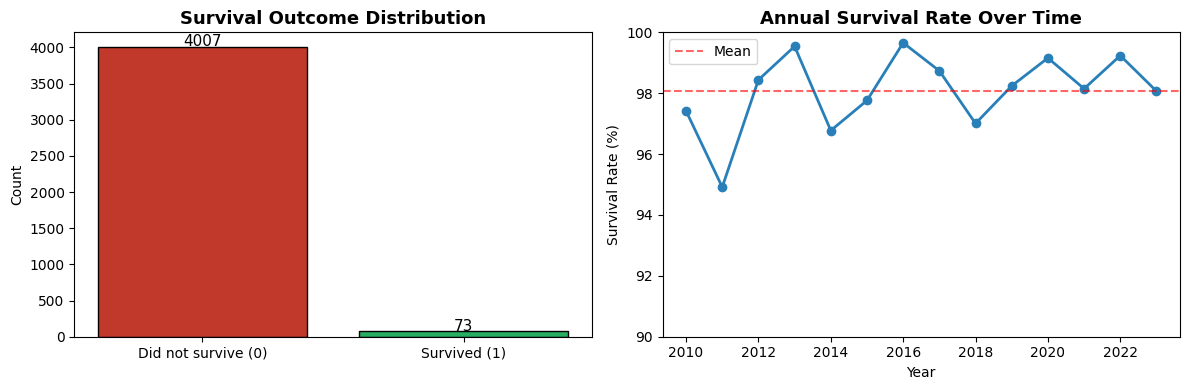

Figure saved.


In [8]:
surv_counts = ind_df['survived_next_year'].value_counts()
surv_pct    = ind_df['survived_next_year'].value_counts(normalize=True) * 100

print("── Target variable: survived_next_year ─────────────────────────────")
print(f"  Survived (1)  : {surv_counts[1]:>5}  ({surv_pct[1]:.1f}%)")
print(f"  Did not (0)   : {surv_counts[0]:>5}  ({surv_pct[0]:.1f}%)")
print(f"  Class imbalance ratio: {surv_counts[1]/surv_counts[0]:.1f}:1")
print("\n  NOTE: ~98% survival is realistic for mountain gorillas in protected")
print("        areas, but requires class-imbalance handling in modeling.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Did not survive (0)', 'Survived (1)'],
            surv_counts.values, color=['#c0392b','#27ae60'], edgecolor='black')
axes[0].set_title('Survival Outcome Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(surv_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Survival rate by year
surv_by_year = ind_df.groupby('year')['survived_next_year'].mean().reset_index()
axes[1].plot(surv_by_year['year'], surv_by_year['survived_next_year'] * 100,
             marker='o', color='#2980b9', linewidth=2, markersize=6)
axes[1].set_title('Annual Survival Rate Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(90, 100)
axes[1].axhline(surv_by_year['survived_next_year'].mean()*100,
                color='red', linestyle='--', alpha=0.6, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join('..','data','01_survival_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## Cell 8 — Rainfall Pattern Visualisation

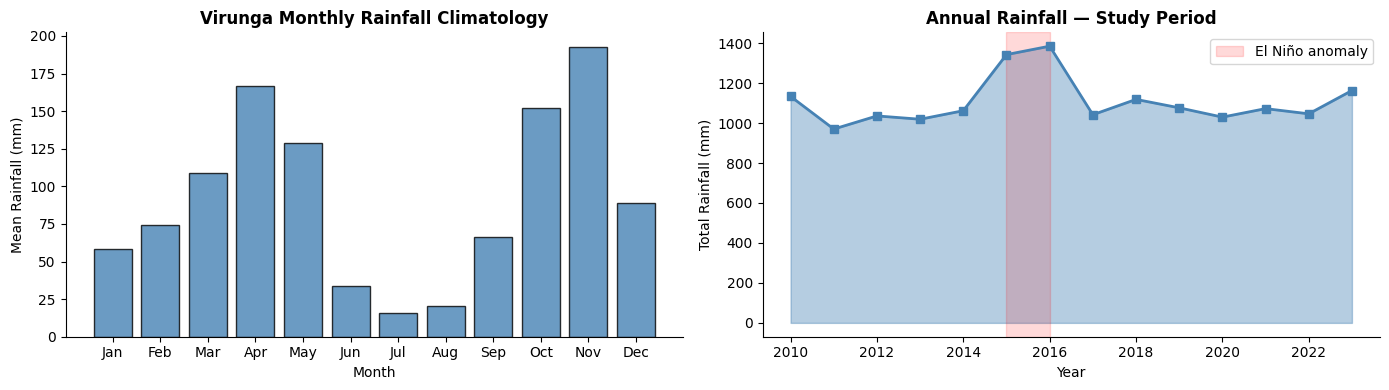

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly climatology
monthly_mean = rain_df.groupby('month')['monthly_rainfall_mm'].mean()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, monthly_mean.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Virunga Monthly Rainfall Climatology', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Rainfall (mm)')
axes[0].set_xlabel('Month')
for spine in ['top','right']: axes[0].spines[spine].set_visible(False)

# Annual total over study period
annual = rain_df.groupby('year')['monthly_rainfall_mm'].sum().reset_index()
axes[1].fill_between(annual['year'], annual['monthly_rainfall_mm'],
                     alpha=0.4, color='steelblue')
axes[1].plot(annual['year'], annual['monthly_rainfall_mm'],
             marker='s', color='steelblue', linewidth=2)
axes[1].set_title('Annual Rainfall — Study Period', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Rainfall (mm)')
axes[1].axvspan(2015, 2016, alpha=0.15, color='red', label='El Niño anomaly')
axes[1].legend()
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join('..','data','01_rainfall_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cell 9 — Group Size Distribution Across All Years

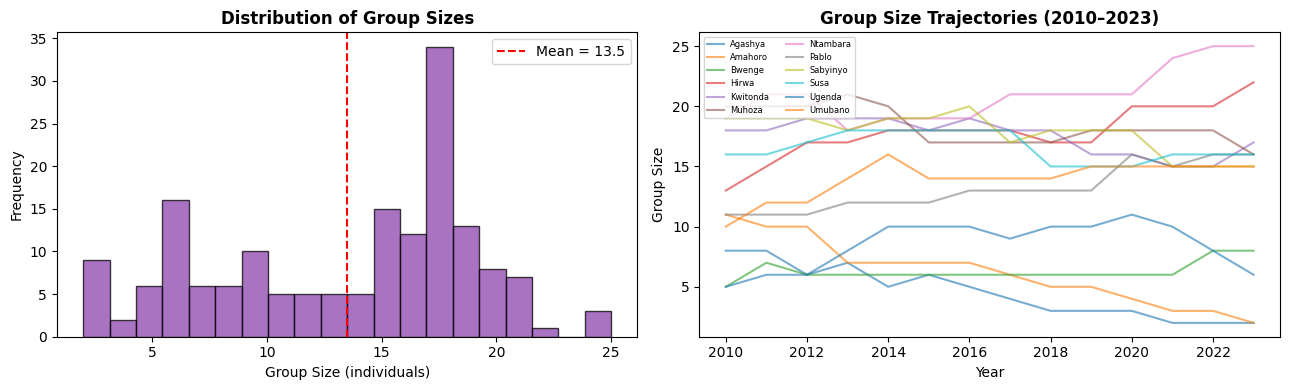


✅ Notebook 01 complete. Proceed to 02_eda_sql.ipynb


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(group_df['group_size'], bins=20, color='#8e44ad', edgecolor='black', alpha=0.75)
axes[0].set_title('Distribution of Group Sizes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group Size (individuals)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(group_df['group_size'].mean(), color='red',
                linestyle='--', label=f"Mean = {group_df['group_size'].mean():.1f}")
axes[0].legend()

# Group size over time per group
pivot = group_df.pivot(index='year', columns='group_name', values='group_size')
for col in pivot.columns:
    axes[1].plot(pivot.index, pivot[col], alpha=0.6, linewidth=1.5, label=col)
axes[1].set_title('Group Size Trajectories (2010–2023)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Group Size')
axes[1].legend(fontsize=6, ncol=2, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join('..','data','01_group_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Notebook 01 complete. Proceed to 02_eda_sql.ipynb")
